# Лабораторная работа

В этом ноутбуке решается задача **регрессии** на датасете **Diabetes** (sklearn).

Требования задания:
- при необходимости обработка пропусков и кодирование категориальных признаков;
- разбиение `train_test_split`;
- обучение моделей: **линейная**, **SVM**, **дерево решений**;
- оценка качества **двумя метриками** и сравнение;
- график важности признаков для дерева;
- визуализация дерева или правила дерева текстом.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set(style="ticks")

## 1) Загрузка данных и проверка на пропуски

Используем `load_diabetes` и соберём данные в `pandas.DataFrame`.

In [2]:
data = load_diabetes(as_frame=True)

df = data.frame.copy()

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
df.isna().sum().sort_values(ascending=False).head(20)

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

### Обработка пропусков и категориальных признаков

- В этом датасете категориальных признаков нет (все признаки числовые). Пропусков в данных также нет (проверка ниже).

In [5]:
assert df.isna().sum().sum() == 0, "В данных пропуски."

## 2) Разбиение train/test

Разобьём выборку на обучающую и тестовую с помощью `train_test_split`.

In [6]:
target_col = "target"

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train.shape, X_test.shape

((353, 10), (89, 10))

## 3) Обучение моделей

Обучим 3 модели:
- **Линейная регрессия** (`LinearRegression`)
- **SVM для регрессии** (`SVR`)
- **Дерево решений** (`DecisionTreeRegressor`)

In [7]:
models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10.0, gamma="scale"))
    ]),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        random_state=1,
        max_depth=6
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)

list(models.keys())

['LinearRegression', 'SVR', 'DecisionTreeRegressor']

## 4) Оценка качества (2 метрики) и сравнение моделей

Для регрессии возьмём две метрики:
- **MAE** (mean absolute error)
- **RMSE** (корень из MSE)

Чем **меньше**, тем лучше.

In [8]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    mae, rmse, r2 = regression_metrics(y_test, y_pred)
    rows.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results = pd.DataFrame(rows).sort_values(by="RMSE")
results

,model,MAE,RMSE,R2
0,LinearRegression,41.974921,54.704490,0.438432
1,SVR,42.631245,56.495974,0.401048
2,DecisionTreeRegressor,54.677170,74.651746,-0.045771


## 5) Важность признаков в дереве решений

Построим график `feature_importances_` для модели `DecisionTreeRegressor`.

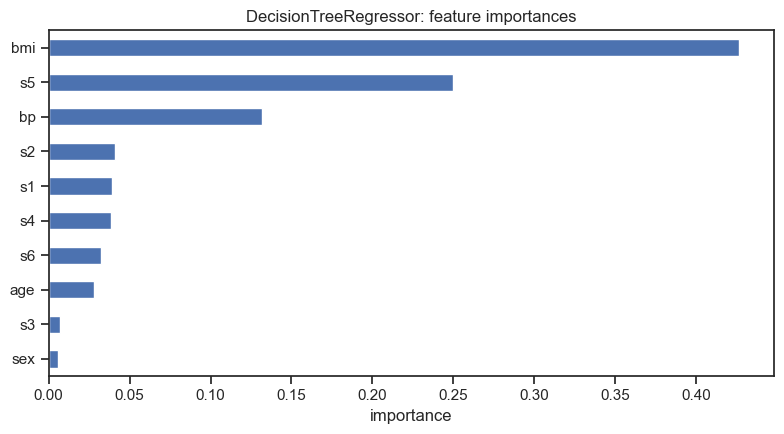

In [9]:
tree_model = models["DecisionTreeRegressor"]

importances = pd.Series(tree_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 4.5))
importances.plot(kind="barh")
plt.title("DecisionTreeRegressor: feature importances")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

## 6) Правила дерева и визуализация

Ниже:
- текстовые правила `export_text`;
- визуализация дерева.

In [10]:
rules = export_text(tree_model, feature_names=list(X.columns))
print(rules[:4000])

|--- bmi <= 0.01
|   |--- s5 <= -0.00
|   |   |--- s5 <= -0.04
|   |   |   |--- age <= -0.09
|   |   |   |   |--- s2 <= -0.05
|   |   |   |   |   |--- s3 <= 0.00
|   |   |   |   |   |   |--- value: [101.00]
|   |   |   |   |   |--- s3 >  0.00
|   |   |   |   |   |   |--- value: [55.00]
|   |   |   |   |--- s2 >  -0.05
|   |   |   |   |   |--- s6 <= -0.01
|   |   |   |   |   |   |--- value: [135.00]
|   |   |   |   |   |--- s6 >  -0.01
|   |   |   |   |   |   |--- value: [200.00]
|   |   |   |--- age >  -0.09
|   |   |   |   |--- s1 <= -0.04
|   |   |   |   |   |--- s1 <= -0.04
|   |   |   |   |   |   |--- value: [84.05]
|   |   |   |   |   |--- s1 >  -0.04
|   |   |   |   |   |   |--- value: [182.00]
|   |   |   |   |--- s1 >  -0.04
|   |   |   |   |   |--- s3 <= 0.02
|   |   |   |   |   |   |--- value: [44.25]
|   |   |   |   |   |--- s3 >  0.02
|   |   |   |   |   |   |--- value: [67.67]
|   |   |--- s5 >  -0.04
|   |   |   |--- age <= 0.07
|   |   |   |   |--- bp <= 0.12
|   |   |  

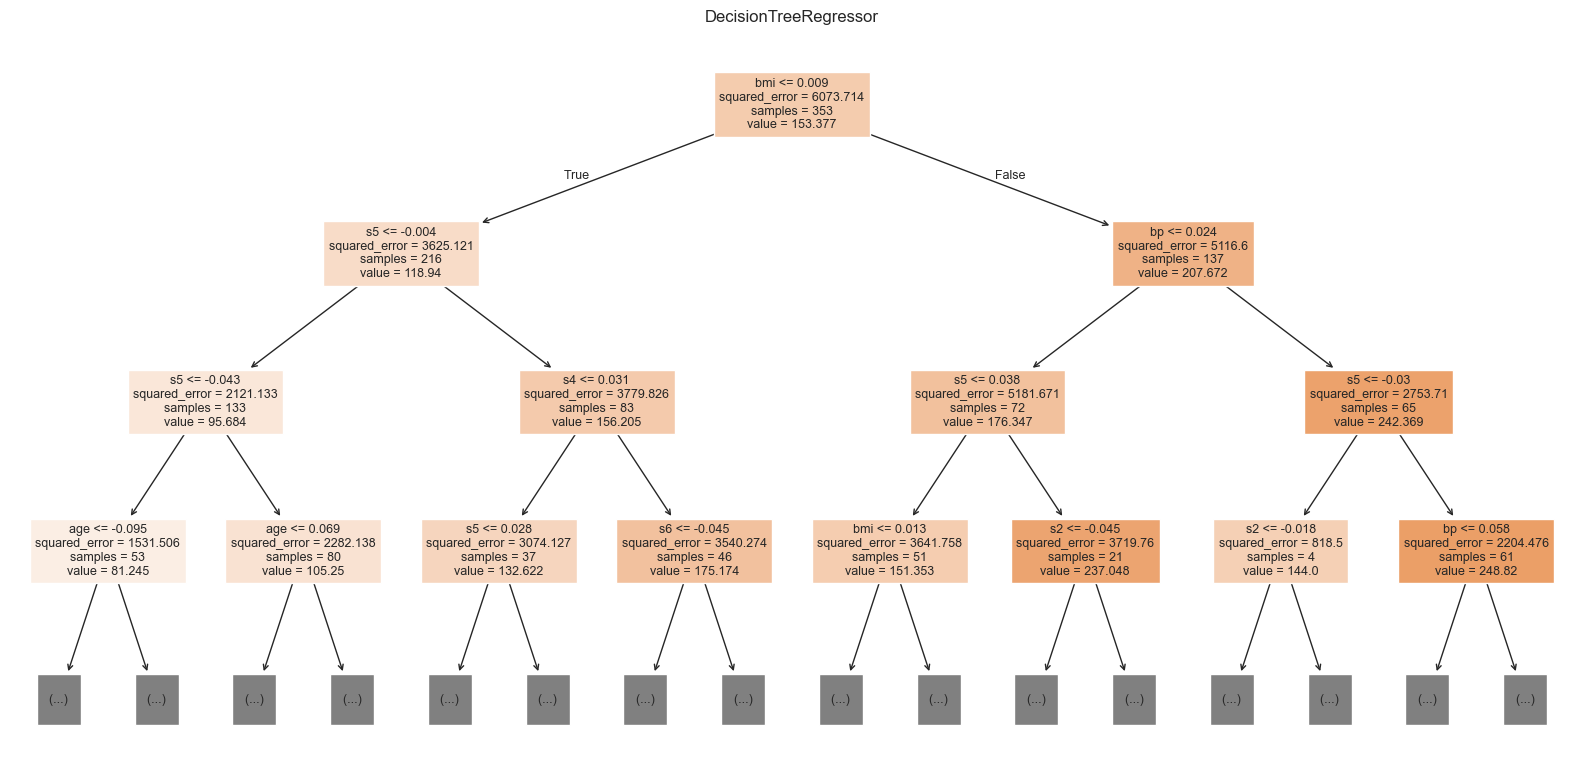

In [11]:
plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=list(X.columns), filled=True, max_depth=3, fontsize=9)
plt.title("DecisionTreeRegressor")
plt.tight_layout()
plt.show()